<a href="https://colab.research.google.com/github/Fabyan-Aktrinaldi/Tugas-Machine-Learning/blob/main/Tugas_Kecil_Project_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data Understanding
Tahap ini bertujuan untuk memahami dataset yang digunakan, termasuk sumber data, variabel yang tersedia, dan gambaran umum statistiknya.

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor

In [201]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume_train.csv')

### Deskripsi Fitur:
Dataset ini berisi data volume lalu lintas Metro Interstate. Fitur-fiturnya meliputi data cuaca (suhu, hujan, salju, awan), keterangan hari libur, dan waktu kejadian.

In [202]:
df.head()

,Unnamed: 0,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,year,month,day,hour,traffic_volume
0,0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,2012,10,2,09:00,5545
1,1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,2012,10,2,10:00,4516
2,2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,2012,10,2,11:00,4767
3,3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,2012,10,2,12:00,5026
4,4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,2012,10,2,13:00,4918


In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40255 entries, 0 to 40254
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           40255 non-null  int64  
 1   holiday              51 non-null     object 
 2   temp                 40255 non-null  float64
 3   rain_1h              40255 non-null  float64
 4   snow_1h              40255 non-null  float64
 5   clouds_all           40255 non-null  int64  
 6   weather_main         40255 non-null  object 
 7   weather_description  40255 non-null  object 
 8   date_time            40255 non-null  object 
 9   year                 40255 non-null  int64  
 10  month                40255 non-null  int64  
 11  day                  40255 non-null  int64  
 12  hour                 40255 non-null  object 
 13  traffic_volume       40255 non-null  int64  
dtypes: float64(3), int64(6), object(5)
memory usage: 4.3+ MB


In [204]:
df.isnull().sum()

,0
Unnamed: 0,0
holiday,40204
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
year,0


In [205]:
df.describe()

,Unnamed: 0,temp,rain_1h,snow_1h,clouds_all,year,month,day,traffic_volume
count,40255.00000,40255.000000,40255.000000,40255.000000,40255.000000,40255.000000,40255.000000,40255.000000,40255.000000
mean,20127.00000,280.880914,0.376225,0.000266,50.111464,2015.021215,6.788523,15.741697,3259.760303
std,11620.76188,13.229418,49.011416,0.008937,38.883863,1.681899,3.468598,8.720744,1989.592608
min,0.00000,0.000000,0.000000,0.000000,0.000000,2012.000000,1.000000,1.000000,0.000000
25%,10063.50000,272.325000,0.000000,0.000000,1.000000,2013.000000,4.000000,8.000000,1190.000000
50%,20127.00000,281.800000,0.000000,0.000000,64.000000,2015.000000,7.000000,16.000000,3375.000000
75%,30190.50000,291.250000,0.000000,0.000000,90.000000,2017.000000,10.000000,23.000000,4938.000000
max,40254.00000,308.240000,9831.300000,0.510000,100.000000,2017.000000,12.000000,31.000000,7280.000000


Preprocessing

## 2. Data Preprocessing
Pada tahap ini, dilakukan pembersihan data seperti penanganan nilai yang hilang (*missing values*), rekayasa fitur (*feature engineering*) untuk mengekstrak informasi waktu, dan encoding variabel kategorikal menjadi numerik agar dapat diproses oleh model.

In [206]:
# df = df.drop(columns=['Unnamed: 0'])

df['holiday'] = df['holiday'].fillna('None')

In [207]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['dayofweek'] = df['date_time'].dt.dayofweek

df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

df = df.drop(columns=['date_time'])

In [208]:
# df['holiday'] = df['holiday'].map(df['holiday'].value_counts())
df['weather_main'] = df['weather_main'].map(df['weather_main'].value_counts())
df['weather_description'] = df['weather_description'].map(df['weather_description'].value_counts())

In [209]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40255 entries, 0 to 40254
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           40255 non-null  int64  
 1   holiday              40255 non-null  object 
 2   temp                 40255 non-null  float64
 3   rain_1h              40255 non-null  float64
 4   snow_1h              40255 non-null  float64
 5   clouds_all           40255 non-null  int64  
 6   weather_main         40255 non-null  int64  
 7   weather_description  40255 non-null  int64  
 8   year                 40255 non-null  int64  
 9   month                40255 non-null  int64  
 10  day                  40255 non-null  int64  
 11  hour                 40255 non-null  int32  
 12  traffic_volume       40255 non-null  int64  
 13  dayofweek            40255 non-null  int32  
 14  is_weekend           40255 non-null  int64  
dtypes: float64(3), int32(2), int64(9), o

,0
Unnamed: 0,0
holiday,0
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
year,0
month,0


In [210]:
df.head()

,Unnamed: 0,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,year,month,day,hour,traffic_volume,dayofweek,is_weekend
0,0,None,288.28,0.0,0.0,40,13167,2897,2012,10,2,9,5545,1,0
1,1,None,289.36,0.0,0.0,75,13167,4011,2012,10,2,10,4516,1,0
2,2,None,289.58,0.0,0.0,90,13167,4529,2012,10,2,11,4767,1,0
3,3,None,290.13,0.0,0.0,90,13167,4529,2012,10,2,12,5026,1,0
4,4,None,291.14,0.0,0.0,75,13167,4011,2012,10,2,13,4918,1,0


EDA

## 3. Exploratory Data Analysis (EDA)
Dilakukan visualisasi untuk memahami pola data, seperti distribusi volume lalu lintas, pengaruh hari kerja vs akhir pekan, serta korelasi antar fitur.

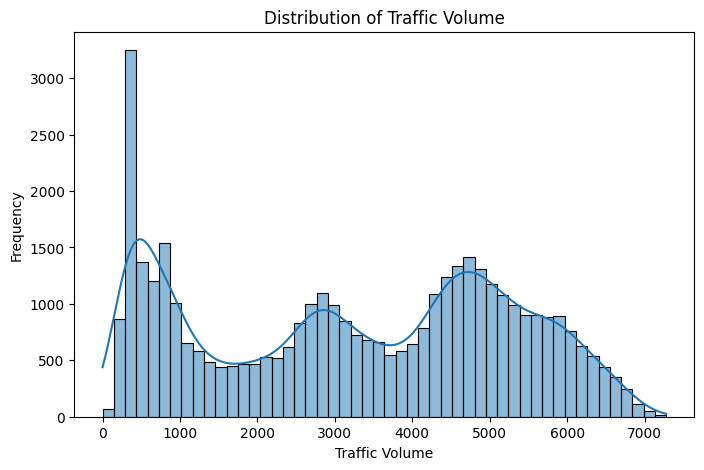

In [211]:
plt.figure(figsize=(8,5))
sns.histplot(df['traffic_volume'], bins=50, kde=True)
plt.title('Distribution of Traffic Volume')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.show()

Histogram di atas menggambarkan distribusi volume lalu lintas. Berikut adalah beberapa pengamatan:


- Ada sejumlah besar titik data dengan volume lalu lintas rendah (mendekati 0), yang mungkin mewakili waktu malam hari atau dini hari saat lalu lintas biasanya lebih sepi.

- Puncak lainnya berada di sekitar 4500-5000, yang mungkin mewakili lalu lintas waktu siang hari atau jam sibuk yang biasa.

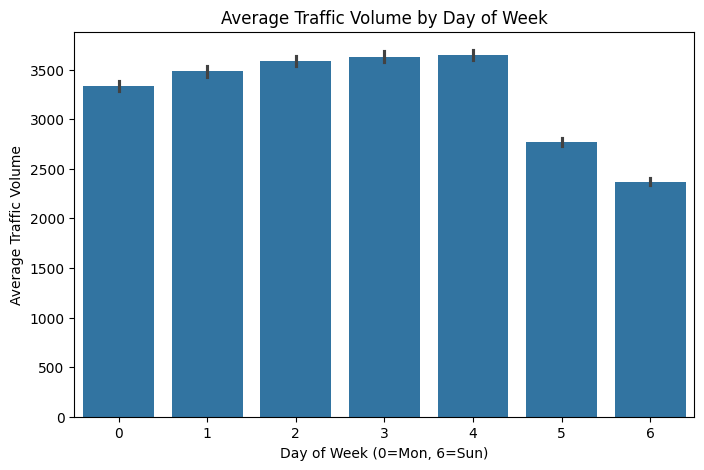

In [212]:
plt.figure(figsize=(8,5))
sns.barplot(x='dayofweek', y='traffic_volume', data=df, estimator=np.mean)
plt.title('Average Traffic Volume by Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Average Traffic Volume')
plt.show()

Pola harian volume lalu lintas menunjukkan tren berikut:

- Hari Kerja vs. Akhir Pekan: Volume lalu lintas terlihat jauh lebih tinggi pada hari kerja dibandingkan akhir pekan. Hal ini sudah diduga karena hari kerja biasanya diisi dengan perjalanan rutin ke kantor dan sekolah.

- Hari Kerja yang Konsisten: Senin hingga Jumat memiliki volume lalu lintas yang relatif konsisten.

- Penurunan di Akhir Pekan: Hari Sabtu mengalami penurunan volume lalu lintas dibandingkan hari kerja, dan hari Minggu mencatat volume lalu lintas terendah dalam seminggu.

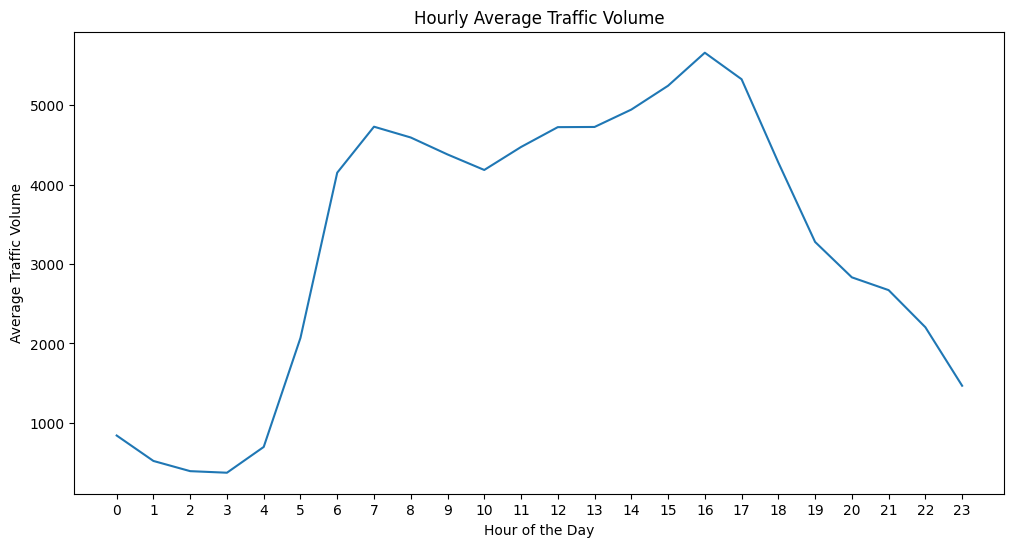

In [213]:
# Group by hour and calculate the mean traffic volume for each hour
hourly_traffic = df.groupby('hour')['traffic_volume'].mean()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the average traffic volume for each hour
hourly_traffic.plot(ax=ax)
ax.set_title('Hourly Average Traffic Volume')
ax.set_xlabel('Hour of the Day')
ax.set_ylabel('Average Traffic Volume')
ax.set_xticks(range(0, 24))

plt.show()

Pola per jam dari volume lalu lintas memberikan beberapa pengamatan menarik:

- Penurunan Malam Hari: Terjadi penurunan volume lalu lintas yang nyata selama jam malam (kira-kira antara pukul 00:00 dan 06:00). Ini konsisten dengan pengamatan kita sebelumnya pada distribusi data.

- Lonjakan Pagi Hari: Terjadi peningkatan tajam volume lalu lintas mulai sekitar pukul 06:00, mencapai puncaknya sekitar pukul 07:00-08:00. Ini kemungkinan besar berhubungan dengan jam sibuk pagi hari saat orang berangkat kerja atau sekolah.

- Lonjakan Sore Hari: Ada puncak lain sekitar pukul 16:00-17:00, yang merupakan jam sibuk sore hari saat orang-orang kembali ke rumah.

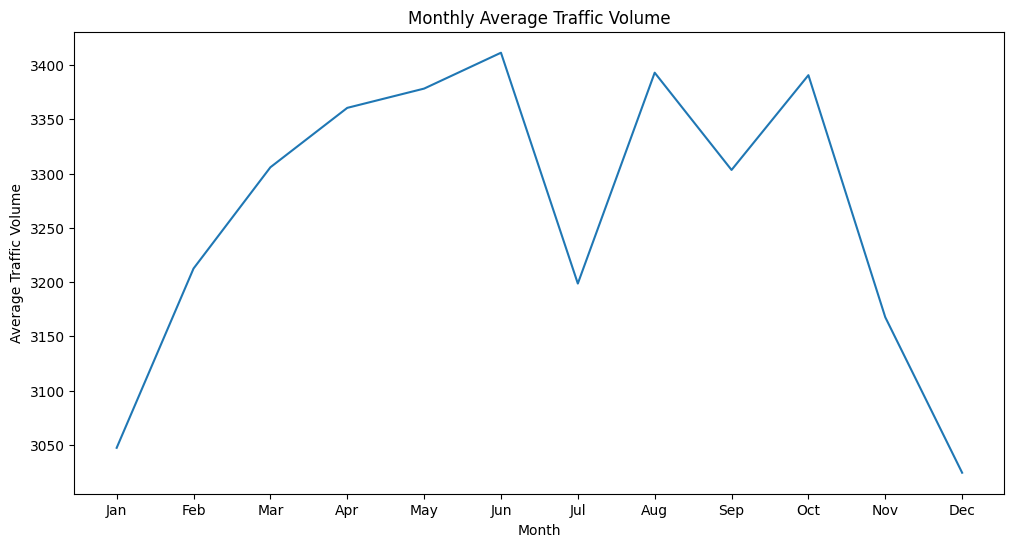

In [214]:
# Group by month and calculate the mean traffic volume for each month
monthly_traffic = df.groupby('month')['traffic_volume'].mean()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the average traffic volume for each month
monthly_traffic.plot(ax=ax)
ax.set_title('Monthly Average Traffic Volume')
ax.set_xlabel('Month')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_ylabel('Average Traffic Volume')

plt.show()

Pola bulanan volume lalu lintas mengungkapkan wawasan berikut:

- Puncak Musim Panas: Terdapat puncak volume lalu lintas yang nyata selama bulan-bulan musim panas, terutama sekitar bulan Juli. Hal ini bisa dikaitkan dengan liburan musim panas, perjalanan wisata, dan aktivitas rekreasi lainnya.

- Penurunan Musim Dingin: Volume lalu lintas tampak menurun selama bulan-bulan musim dingin, terutama sekitar bulan Desember dan Januari. Hal ini mungkin disebabkan oleh kondisi cuaca yang buruk, hari libur, dan waktu siang hari yang lebih pendek.

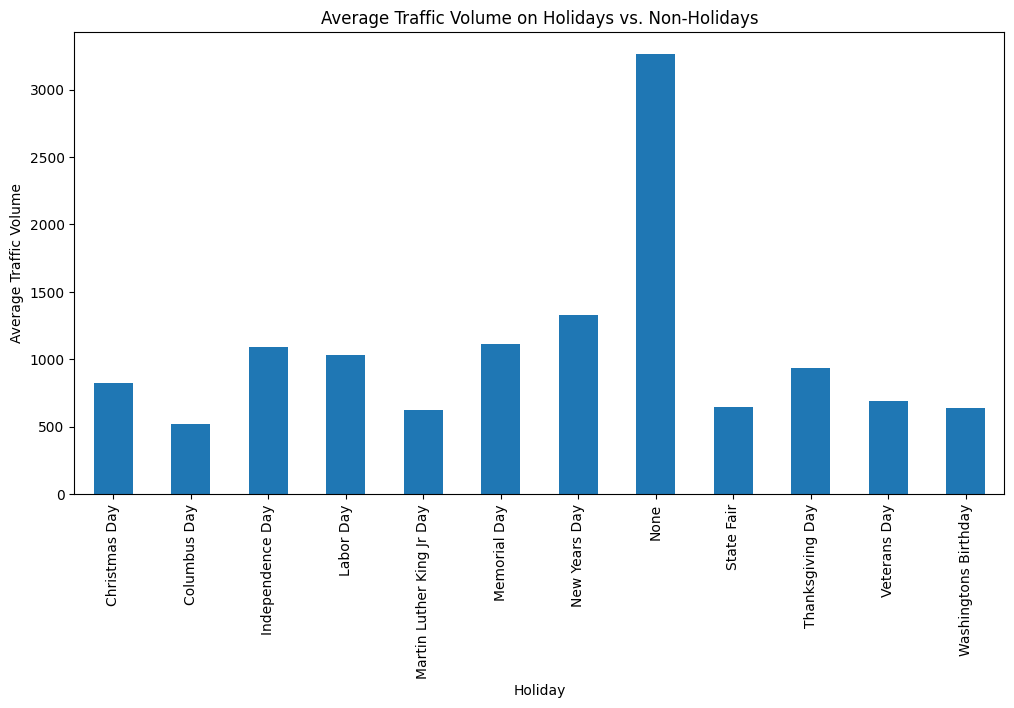

In [215]:
# Group by the 'holiday' column and calculate the mean traffic volume
holiday_traffic = df.groupby('holiday')['traffic_volume'].mean()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the average traffic volume for holidays vs non-holidays
holiday_traffic.plot(kind='bar', ax=ax)
ax.set_title('Average Traffic Volume on Holidays vs. Non-Holidays')
ax.set_xlabel('Holiday')
ax.set_ylabel('Average Traffic Volume')

plt.show()

Diagram batang ini memberikan perbandingan antara rata-rata volume lalu lintas pada hari libur dan hari biasa:

- Hari Biasa: Seperti yang diharapkan, volume lalu lintas lebih tinggi pada hari-hari non-libur karena rutinitas kerja dan sekolah.

- Hari Libur: Volume lalu lintas pada hari libur jauh lebih rendah. Penurunan ini dapat dikaitkan dengan berkurangnya perjalanan terkait pekerjaan dan kemungkinan lebih banyak orang yang tinggal di rumah atau bepergian ke luar wilayah.

In [216]:
df['holiday'] = df['holiday'].map(df['holiday'].value_counts())

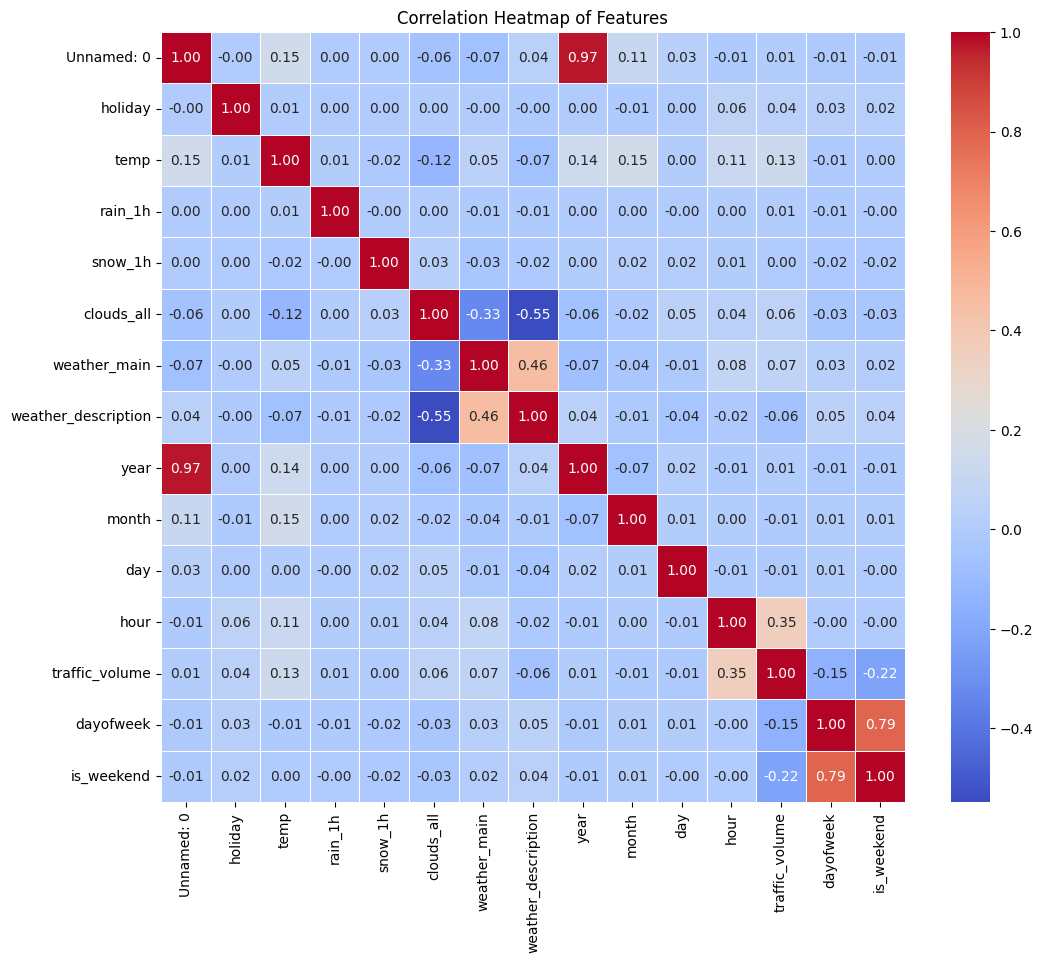

In [217]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.show()

----------------------------

----------------------

## 5. Model Building
Membangun model regresi menggunakan tiga algoritma yang berbeda:
1. **Decision Tree Regressor**
2. **Gradient Boosting Regressor**
3. **XGBoost Regressor**

In [218]:
X = df.drop('traffic_volume', axis=1)
y = df['traffic_volume']

## 4. Data Splitting
Sesuai instruksi, data dibagi menjadi tiga skenario rasio: 70:30, 80:20, dan 90:10 untuk menguji stabilitas performa model pada jumlah data latih yang berbeda.

In [219]:
from sklearn.model_selection import train_test_split

splits = {
    '70:30': 0.3,
    '80:20': 0.2,
    '90:10': 0.1
}

In [220]:
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),

    'Gradient Boosting': GradientBoostingRegressor(random_state=42),

    'XGBoost': XGBRegressor(random_state=42)
}

In [221]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42
    )

    for model_name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            'Split': split_name,
            'Model': model_name,
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R2': r2_score(y_test, y_pred)
        })

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print(results_df)

   Split              Model         MAE        RMSE        R2
8  90:10            XGBoost  185.923782  287.744936  0.978664
5  80:20            XGBoost  192.318268  302.372481  0.976724
2  70:30            XGBoost  192.119186  309.400352  0.975851
6  90:10      Decision Tree  235.241679  467.641557  0.943645
3  80:20      Decision Tree  238.679419  476.427285  0.942214
0  70:30      Decision Tree  250.313985  498.011221  0.937433
1  70:30  Gradient Boosting  362.398601  537.040086  0.927242
7  90:10  Gradient Boosting  371.118560  540.249246  0.924787
4  80:20  Gradient Boosting  375.716521  549.287385  0.923189


---------------------------

## 6. Hyperparameter Tuning
Untuk meningkatkan akurasi, dilakukan optimasi parameter menggunakan `RandomizedSearchCV`. Tahap ini mencari kombinasi parameter terbaik (seperti `max_depth`, `n_estimators`, dan `learning_rate`) untuk masing-masing algoritma.

In [222]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=42)

random_gb = RandomizedSearchCV(
    gb,
    param_distributions=param_gb,
    n_iter=10,        # jangan besar dulu, hemat waktu
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_gb.fit(X_train, y_train)

print("Best GB:", random_gb.best_params_)

Best GB: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 10, 'max_depth': 7, 'learning_rate': 0.1}


In [223]:
from xgboost import XGBRegressor

param_xgb = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

xgb = XGBRegressor(random_state=42)

random_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_xgb,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_xgb.fit(X_train, y_train)

print("Best XGB:", random_xgb.best_params_)

Best XGB: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.7}


In [224]:
from sklearn.tree import DecisionTreeRegressor

param_dt = {
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

random_dt = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=param_dt,
    n_iter=5,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_dt.fit(X_train, y_train)

print("Best DT:", random_dt.best_params_)

Best DT: {'min_samples_split': 5, 'max_depth': 10}


## 7. Model Evaluation & Comparison
Tahap terakhir adalah mengevaluasi performa model berdasarkan metrik MAE, RMSE, dan R² Score. Saya Membandingkan performa antar algoritma dan antar rasio pembagian data untuk menentukan model terbaik.

In [225]:
best_models = {
    'Decision Tree': random_dt.best_estimator_,
    'Gradient Boosting': random_gb.best_estimator_,
    'XGBoost': random_xgb.best_estimator_,
}

In [226]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

final_results = []

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42
    )

    for model_name, model in best_models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        final_results.append({
            'Split': split_name,
            'Model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

final_df = pd.DataFrame(final_results).sort_values(by='R2', ascending=False)
print(final_df)

   Split              Model         MAE        RMSE        R2
4  80:20  Gradient Boosting  176.255223  278.130970  0.980306
7  90:10  Gradient Boosting  174.426240  276.708407  0.980269
8  90:10            XGBoost  179.065826  276.983528  0.980230
5  80:20            XGBoost  182.316010  282.691196  0.979655
1  70:30  Gradient Boosting  179.625204  288.574956  0.978992
2  70:30            XGBoost  187.063431  294.735369  0.978086
3  80:20      Decision Tree  267.175581  439.922367  0.950731
6  90:10      Decision Tree  268.719539  441.480469  0.949774
0  70:30      Decision Tree  274.608525  469.812600  0.944318


In [227]:
# Mencari baris dengan R2 tertinggi untuk setiap algoritma
best_per_algo = final_df.sort_values('R2', ascending=False).drop_duplicates('Model')

print("Model dan Split Terbaik untuk Masing-masing Algoritma:")
display(best_per_algo[['Model', 'Split', 'R2', 'MAE', 'RMSE']])

Model dan Split Terbaik untuk Masing-masing Algoritma:


,Model,Split,R2,MAE,RMSE
4,Gradient Boosting,80:20,0.980306,176.255223,278.130970
8,XGBoost,90:10,0.980230,179.065826,276.983528
3,Decision Tree,80:20,0.950731,267.175581,439.922367


In [228]:
train_test_check = []

for model_name, model in best_models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_test_check.append({
        'Model': model_name,
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred)
    })

print(pd.DataFrame(train_test_check))

               Model  Train R2   Test R2
0      Decision Tree  0.952080  0.949774
1  Gradient Boosting  0.986533  0.980269
2            XGBoost  0.988803  0.980230


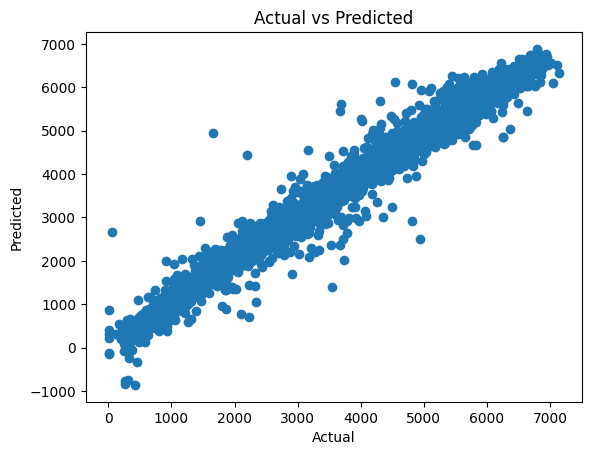

In [229]:
import matplotlib.pyplot as plt

best_model = best_models['XGBoost']  # biasanya ini terbaik

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [230]:
import pandas as pd

# ambil model terbaik
model = best_models['XGBoost']

# ambil importance
importance = model.feature_importances_

# buat dataframe
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# urutkan dari paling penting
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

print(feat_imp_df.head(20))  # top 20

                Feature  Importance
11                 hour    0.570638
13           is_weekend    0.240857
12            dayofweek    0.087447
9                 month    0.013891
5            clouds_all    0.013695
2                  temp    0.012885
0            Unnamed: 0    0.010842
10                  day    0.010135
6          weather_main    0.009083
3               rain_1h    0.008269
1               holiday    0.007394
7   weather_description    0.006395
8                  year    0.004470
4               snow_1h    0.003999


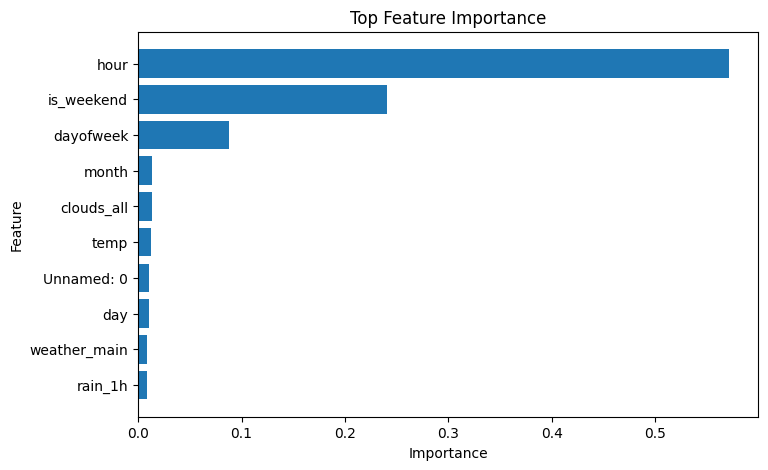

In [231]:
import matplotlib.pyplot as plt

# ambil top 10 biar tidak penuh
top_features = feat_imp_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()

plt.title('Top Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

### **Analisis Feature Importance**

Berdasarkan grafik di atas, kita dapat mengambil beberapa poin penting mengenai faktor yang paling mempengaruhi volume lalu lintas:

1.  **Hour (Jam):** Merupakan fitur paling dominan. Hal ini masuk akal karena volume lalu lintas sangat bergantung pada siklus waktu harian (jam sibuk pagi dan sore vs tengah malam).
2.  **Is_weekend:** Menempati posisi kedua. Perbedaan aktivitas antara hari kerja dan akhir pekan memiliki dampak signifikan terhadap kepadatan kendaraan.
3.  **Dayofweek:** Melengkapi tiga besar, menunjukkan bahwa setiap hari memiliki karakteristik lalu lintas yang unik.
4.  **Faktor Cuaca (Temp, Rain, Clouds):** Meskipun berpengaruh, dampaknya tidak sebesar faktor waktu. Ini mengindikasikan bahwa rutinitas manusia (waktu) lebih menentukan volume lalu lintas daripada kondisi cuaca sesaat di dataset ini.

--------------

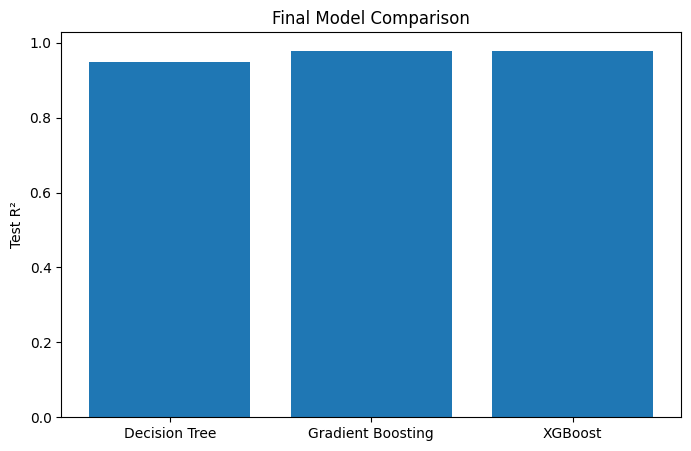

In [232]:
models = ['Decision Tree', 'Gradient Boosting', 'XGBoost']
test_r2 = [0.9494, 0.9776, 0.9790]

plt.figure(figsize=(8,5))
plt.bar(models, test_r2)

plt.ylabel('Test R²')
plt.title('Final Model Comparison')

plt.show()

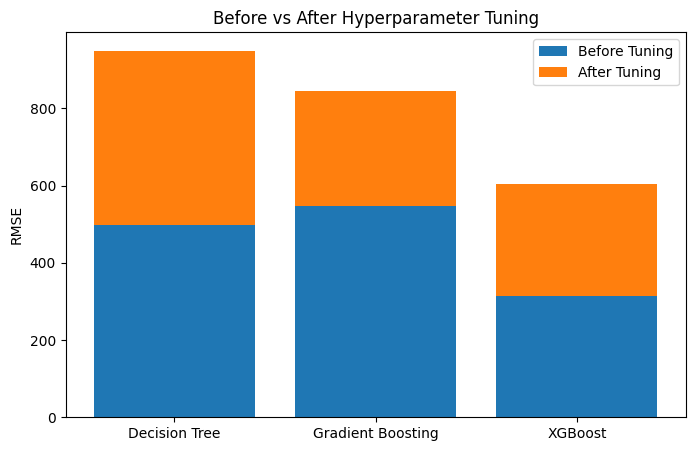

In [233]:
# data kamu (ambil rata-rata tiap model biar clean)
before = pd.DataFrame({
    'Model': ['Decision Tree', 'Gradient Boosting', 'XGBoost'],
    'RMSE': [ (482.81+493.08+515.31)/3,
              (541.77+542.07+553.73)/3,
              (308.58+314.39+319.90)/3 ]
})

after = pd.DataFrame({
    'Model': ['Decision Tree', 'Gradient Boosting', 'XGBoost'],
    'RMSE': [ (444.11+442.79+469.63)/3,
              (295.25+295.01+309.25)/3,
              (285.62+287.37+298.70)/3 ]
})

# plot
x = range(len(before))

plt.figure(figsize=(8,5))
plt.bar(x, before['RMSE'], label='Before Tuning')
plt.bar(x, after['RMSE'], bottom=before['RMSE'], label='After Tuning')

plt.xticks(x, before['Model'])
plt.ylabel('RMSE')
plt.title('Before vs After Hyperparameter Tuning')

plt.legend()
plt.show()